# 01 — Exploration des données

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.utils import (
    load_animal_data, ANIMAL_CLASSES, ANIMAL_INDICES,
    unpickle, DATA_DIR
)

In [3]:
X_train, y_train, X_test, y_test = load_animal_data()
print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

def to_img(flat):
    return flat.reshape(3, 32, 32).transpose(1, 2, 0)

Train : (30000, 3072)
Test  : (6000, 3072)


/Users/antoinegobbe/Desktop/Plateforme/neuralzoo/src/utils.py:14: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding='bytes')


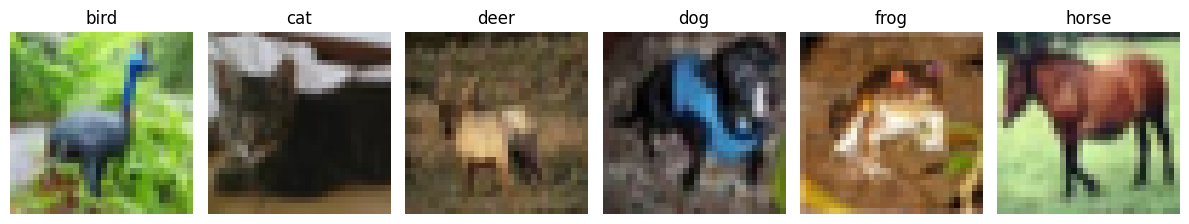

In [4]:
fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for ax, (name, idx) in zip(axes, ANIMAL_CLASSES.items()):
    i = np.where(y_train == idx)[0][0]
    ax.imshow(to_img(X_train[i]))
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [5]:
meta = unpickle(str(DATA_DIR / 'batches.meta'))
label_names = [name.decode() for name in meta[b'label_names']]

In [6]:
all_data, all_labels = [], []
for i in range(1, 6):
    d = unpickle(str(DATA_DIR / f'data_batch_{i}'))
    all_data.append(d[b'data'])
    all_labels.extend(d[b'labels'])
X_full = np.vstack(all_data)
y_full = np.array(all_labels)
test_full = unpickle(str(DATA_DIR / 'test_batch'))
y_test_full = np.array(test_full[b'labels'])

print("=== Dataset complet (10 classes) ===")
print(f"Train total : {X_full.shape[0]:,} images")
print(f"Test total  : {y_test_full.shape[0]:,} images")
print(f"Total       : {X_full.shape[0] + y_test_full.shape[0]:,} images")

print("\n=== Après filtrage animaux (6 classes) ===")
print(f"Train : {X_train.shape[0]:,} images  ({X_train.shape[0]/X_full.shape[0]*100:.0f}% du train original)")
print(f"Test  : {X_test.shape[0]:,} images   ({X_test.shape[0]/y_test_full.shape[0]*100:.0f}% du test original)")
print(f"Total : {X_train.shape[0] + X_test.shape[0]:,} images")

# %%
# Répartition par classe
print(f"{'Classe':<10} {'Train':>8} {'Test':>8} {'Total':>8} {'% train':>10}")
print("-" * 50)
for name, idx in ANIMAL_CLASSES.items():
    n_train = np.sum(y_train == idx)
    n_test  = np.sum(y_test == idx)
    print(f"{name:<10} {n_train:>8,} {n_test:>8,} {n_train+n_test:>8,} {n_train/(n_train+n_test)*100:>9.1f}%")

=== Dataset complet (10 classes) ===
Train total : 50,000 images
Test total  : 10,000 images
Total       : 60,000 images

=== Après filtrage animaux (6 classes) ===
Train : 30,000 images  (60% du train original)
Test  : 6,000 images   (60% du test original)
Total : 36,000 images
Classe        Train     Test    Total    % train
--------------------------------------------------
bird          5,000    1,000    6,000      83.3%
cat           5,000    1,000    6,000      83.3%
deer          5,000    1,000    6,000      83.3%
dog           5,000    1,000    6,000      83.3%
frog          5,000    1,000    6,000      83.3%
horse         5,000    1,000    6,000      83.3%


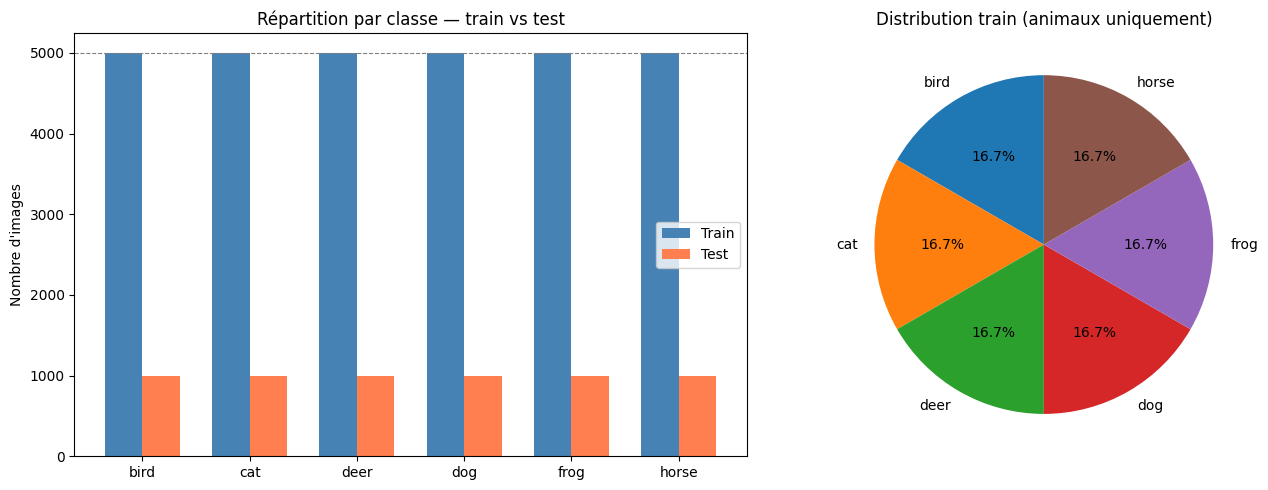

In [7]:
classes      = list(ANIMAL_CLASSES.keys())
train_counts = [np.sum(y_train == idx) for idx in ANIMAL_CLASSES.values()]
test_counts  = [np.sum(y_test  == idx) for idx in ANIMAL_CLASSES.values()]
x, width     = np.arange(len(classes)), 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(x - width/2, train_counts, width, label='Train', color='steelblue')
axes[0].bar(x + width/2, test_counts,  width, label='Test',  color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes)
axes[0].set_title('Répartition par classe — train vs test')
axes[0].set_ylabel("Nombre d'images")
axes[0].legend()
axes[0].axhline(y=5000, color='gray', linestyle='--', linewidth=0.8)
axes[1].pie(train_counts, labels=classes, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribution train (animaux uniquement)')
plt.tight_layout()
plt.show()

Valeurs pixel — min: 0, max: 255, mean: 115.0, std: 61.2


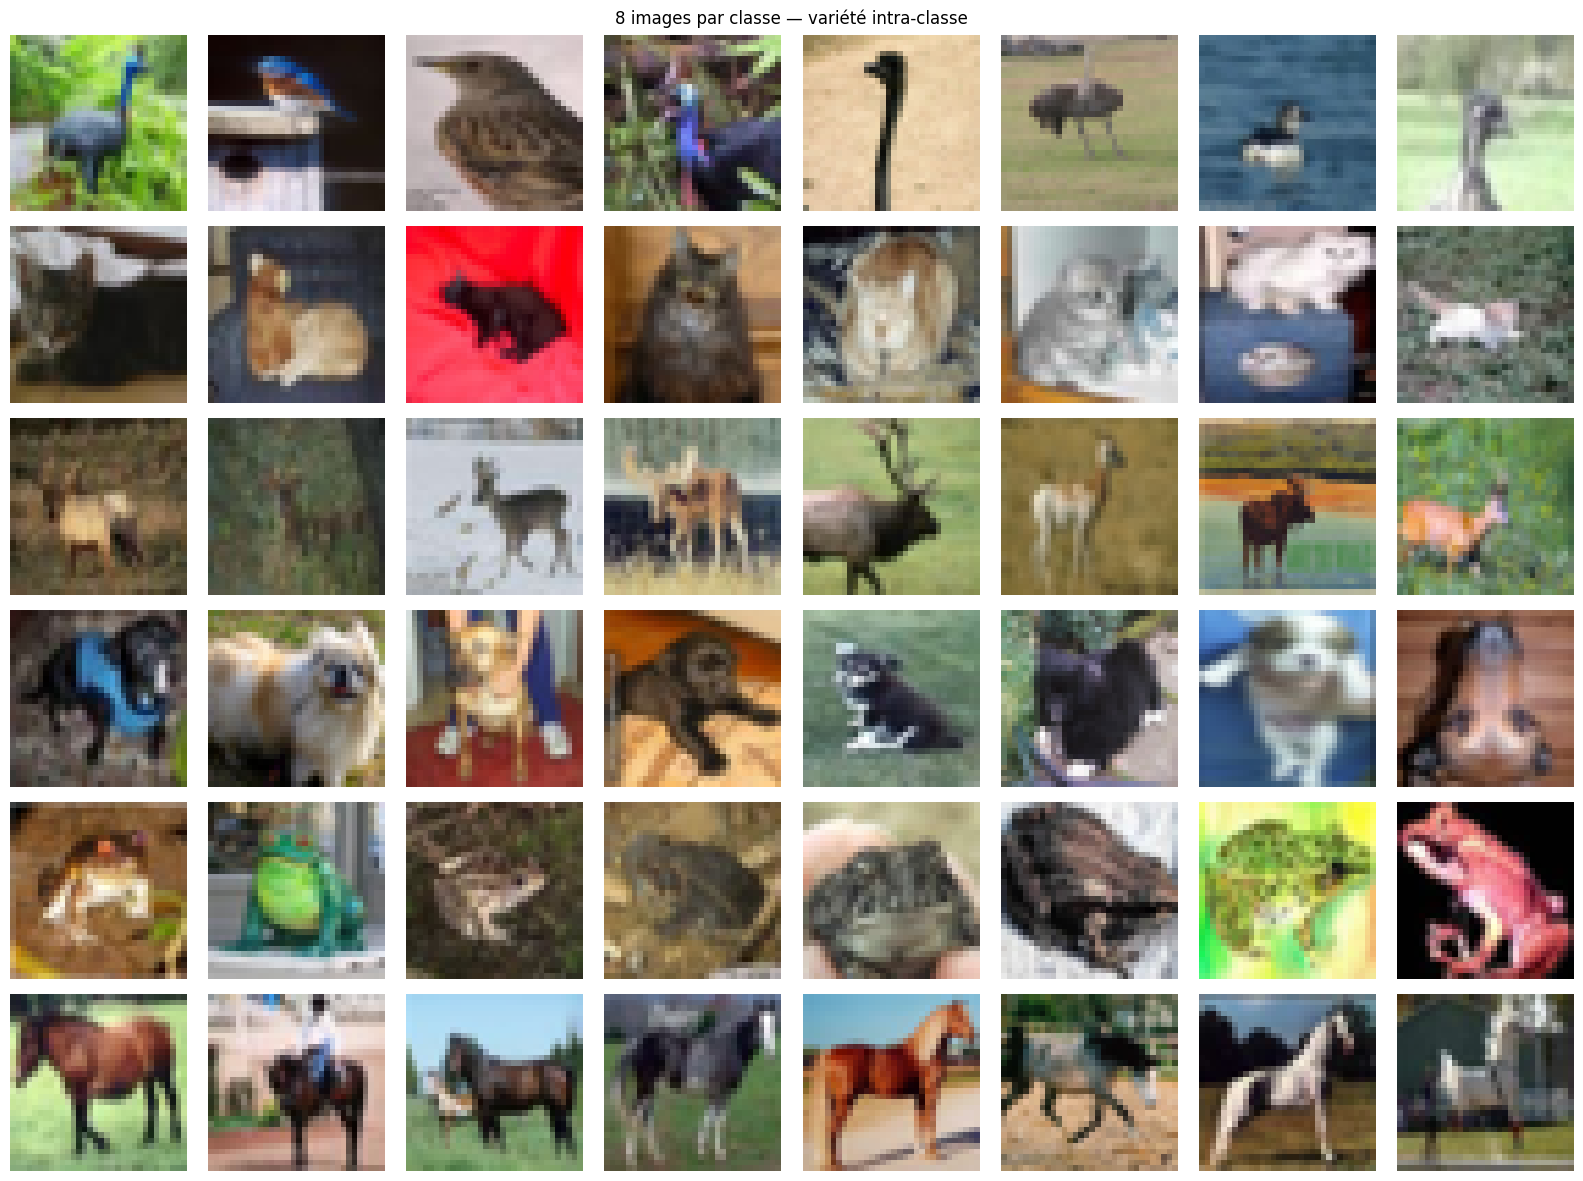

In [8]:
print(f"Valeurs pixel — min: {X_train.min()}, max: {X_train.max()}, mean: {X_train.mean():.1f}, std: {X_train.std():.1f}")

fig, axes = plt.subplots(6, 8, figsize=(16, 12))
for row, (name, idx) in enumerate(ANIMAL_CLASSES.items()):
    samples = X_train[y_train == idx][:8]
    for col, img in enumerate(samples):
        axes[row][col].imshow(to_img(img))
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(name, rotation=0, labelpad=40, fontsize=10)
plt.suptitle("8 images par classe — variété intra-classe")
plt.tight_layout()
plt.show()

# Conclusion de l'analyse exploratoire



- **Volume et classes** : Le dataset CIFAR-10 contient 60 000 images réparties en 10 classes. Après filtrage sur les 6 classes animales (bird, cat, deer, dog, frog, horse), nous travaillons sur 36 000 images (60% du dataset original).



- **Équilibre** : Le dataset est parfaitement équilibré : 5 000 images par classe en train et 1 000 en test. Aucun problème de déséquilibre de classes à gérer, ce qui simplifie l'entraînement et l'interprétation des métriques.



- **Format** : Les images sont en 32×32 pixels RGB, stockées à plat (3072 valeurs). Cette résolution basse rend la tâche difficile, même pour un humain (ex : distinction cat vs dog).



- **Statistiques pixel** : Les pixels sont dans [0, 255], moyenne 115, écart-type 61. Une normalisation vers [0, 1] est nécessaire avant l'entraînement pour stabiliser la descente de gradient.



- **Variété intra-classe** : La grille de 8 images par classe montre une forte diversité de poses, orientations et fonds. Cela justifie l'utilisation d'un CNN plutôt qu'un MLP : le CNN apprend des features spatiales locales (contours, textures), là où le MLP traite chaque pixel indépendamment.



**Lien avec la modélisation (notebook 02)** :

- Normalisation des pixels

- Utilisation de BatchNormalization

- Architecture CNN comme modèle principal

